<a href="https://colab.research.google.com/github/ArtemNyow/university-Deep-Learning-lb1/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 1028.8517 - mae: 22.6230 - val_loss: 933.9023 - val_mae: 21.0070
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 990.6393 - mae: 21.8865 - val_loss: 904.5694 - val_mae: 20.5238
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 959.1017 - mae: 21.4359 - val_loss: 852.7302 - val_mae: 19.6399
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 951.7042 - mae: 20.9012 - val_loss: 764.0689 - val_mae: 18.0858
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 773.4960 - mae: 18.2080 - val_loss: 637.0070 - val_mae: 15.8745
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 661.6568 - mae: 16.2658 - val_loss: 482.5171 - val_mae: 13.8461
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 531.7322 - mae: 14.7935 - val_loss: 345.4057 - val_mae: 12.5407
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 332.0424 - mae: 12.4384 - val_loss: 261.5466 - val_mae: 12.2715
Epoch 9/200
25

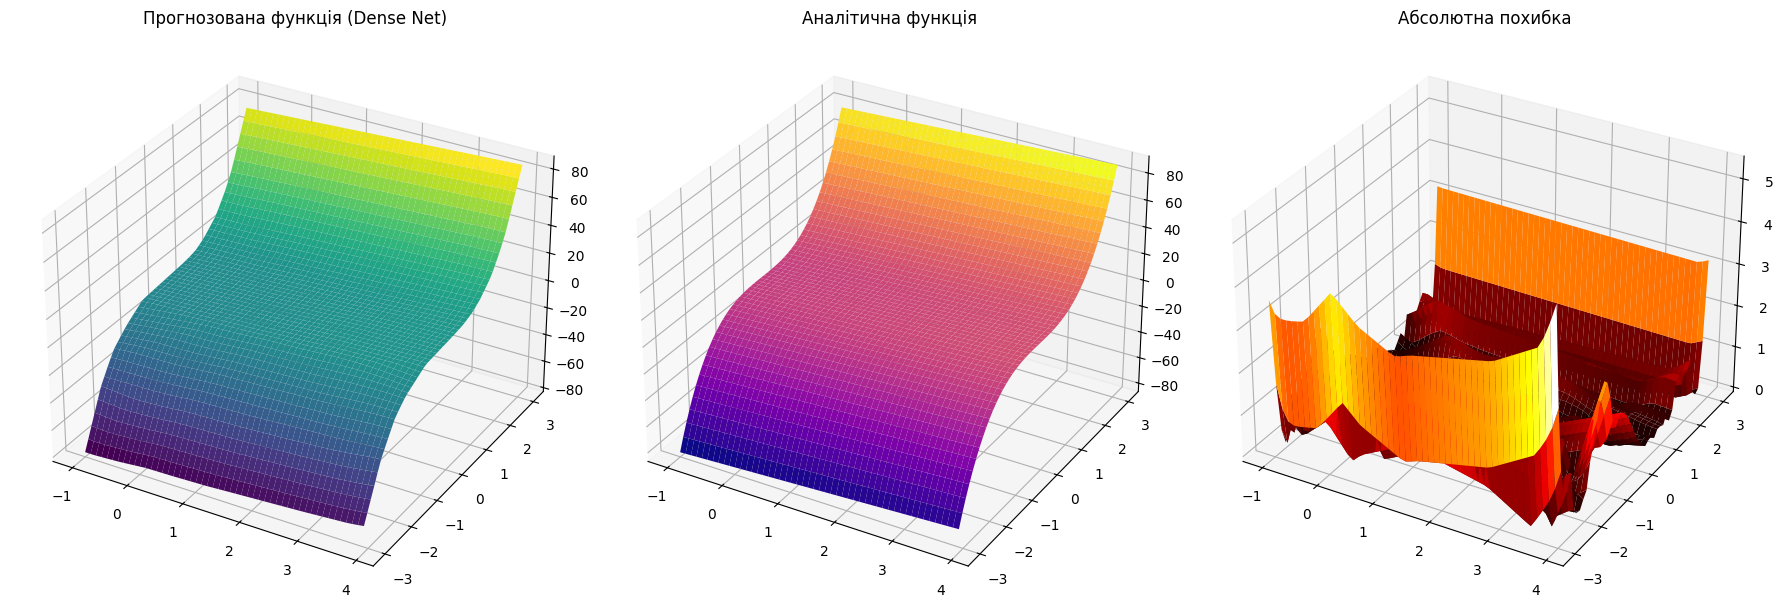

Epoch 1/200


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 999.2452 - mae: 21.7536 - val_loss: 925.7544 - val_mae: 20.8976
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 984.7687 - mae: 21.8587 - val_loss: 880.6463 - val_mae: 20.1894
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 920.0992 - mae: 20.4618 - val_loss: 796.2700 - val_mae: 18.8277
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 799.7789 - mae: 19.0302 - val_loss: 662.5748 - val_mae: 16.6821
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 643.3228 - mae: 16.6098 - val_loss: 501.0791 - val_mae: 14.2326
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 465.8207 - mae: 14.3104 - val_loss: 358.6617 - val_mae: 12.9529
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 370.3296 - mae: 13.7570 - val_loss: 278.0666 - val_mae: 12.7667
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 260.4822 - mae: 12.5677 - val_loss: 246.6806 - val_mae: 12.8864
Epoch 9/200
25/25 ━━━━━━━━━

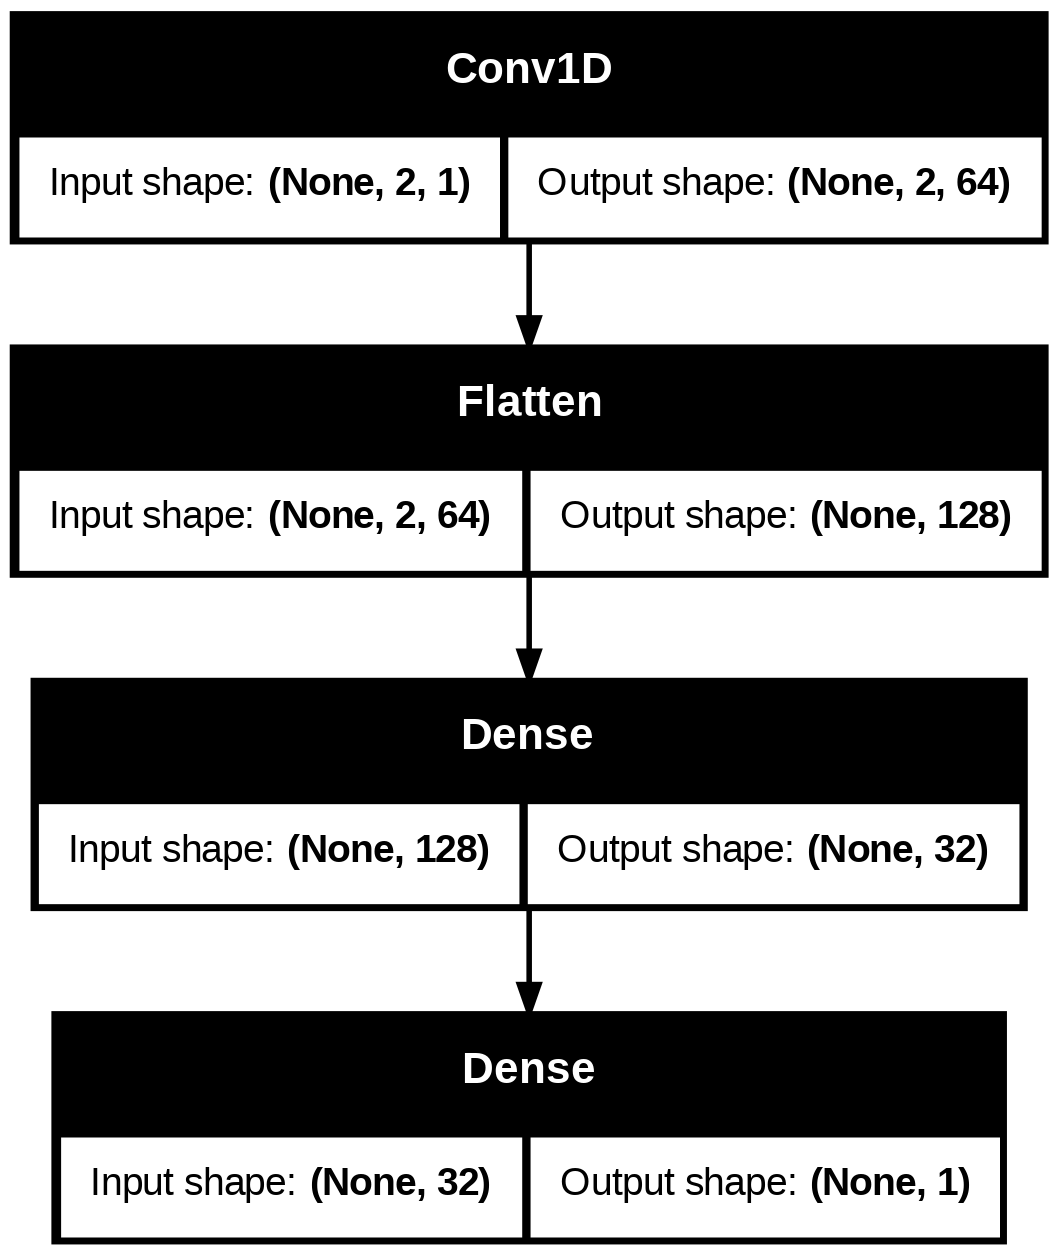

In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten
from tensorflow.keras.utils import plot_model

# 1. Генерація датасету (з першої лабораторної)
np.random.seed(42)
x = np.random.uniform(-1, 5*np.pi/4, 1000)
y = np.random.uniform(-3, 3, 1000)
F2 = 2*x + 3*y**3  # Аналітична функція

# 2. Підготовка даних
X = np.column_stack((x, y))
X_train, X_test, y_train, y_test = train_test_split(X, F2, test_size=0.2, random_state=42)

# Нормалізація
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Побудова Dense-мережі
def build_dense_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(2,)),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# 4. Навчання моделі
dense_model = build_dense_model()
history = dense_model.fit(
    X_train_scaled, y_train,
    epochs=200,  # Збільшено кількість епох
    batch_size=32,
    validation_data=(X_test_scaled, y_test)
)

# 5. Оцінка якості
test_loss, test_mae = dense_model.evaluate(X_test_scaled, y_test)
print(f'Dense Network - Test MSE: {test_loss:.4f}, MAE: {test_mae:.4f}')

# 6. Візуалізація результатів
def plot_3d_comparison():
    # Створення сітки для візуалізації
    x_grid = np.linspace(-1, 5*np.pi/4, 50)
    y_grid = np.linspace(-3, 3, 50)
    x_mesh, y_mesh = np.meshgrid(x_grid, y_grid)
    grid_points = np.c_[x_mesh.ravel(), y_mesh.ravel()]

    # Прогноз моделі
    grid_scaled = scaler.transform(grid_points)
    z_pred = dense_model.predict(grid_scaled).reshape(x_mesh.shape)

    # Аналітичні значення
    z_true = 2*x_mesh + 3*y_mesh**3

    # Побудова графіків
    fig = plt.figure(figsize=(18, 6))

    # Прогнозована функція
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.plot_surface(x_mesh, y_mesh, z_pred, cmap='viridis')
    ax1.set_title('Прогнозована функція (Dense Net)')

    # Аналітична функція
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.plot_surface(x_mesh, y_mesh, z_true, cmap='plasma')
    ax2.set_title('Аналітична функція')

    # Похибка
    ax3 = fig.add_subplot(133, projection='3d')
    error = np.abs(z_true - z_pred)
    ax3.plot_surface(x_mesh, y_mesh, error, cmap='hot')
    ax3.set_title('Абсолютна похибка')

    plt.tight_layout()
    plt.show()

plot_3d_comparison()

# 7. Експерименти з іншими архітектурами
def build_cnn_model():
    model = Sequential([
        Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(2, 1)),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Підготовка даних для CNN
X_train_cnn = X_train_scaled.reshape(-1, 2, 1)
X_test_cnn = X_test_scaled.reshape(-1, 2, 1)

# Навчання CNN
cnn_model = build_cnn_model()
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test_cnn, y_test)
)

# Оцінка CNN
cnn_loss, cnn_mae = cnn_model.evaluate(X_test_cnn, y_test)
print(f'CNN - Test MSE: {cnn_loss:.4f}, MAE: {cnn_mae:.4f}')

# 8. Порівняння моделей
models = {
    'Dense': dense_model,
    'CNN': cnn_model
}

for name, model in models.items():
    if 'CNN' in name:
        X_test_ = X_test_cnn
    else:
        X_test_ = X_test_scaled

    y_pred = model.predict(X_test_).flatten()
    mse = mean_squared_error(y_test, y_pred)
    mae = np.mean(np.abs(y_test - y_pred))

    print(f'\n{name} Network:')
    print(f'- MSE: {mse:.4f}')
    print(f'- MAE: {mae:.4f}')
    print(f'- Максимальна похибка: {np.max(np.abs(y_test - y_pred)):.4f}')

# 9. Візуалізація архітектур
plot_model(dense_model, to_file='dense_architecture.png', show_shapes=True)
plot_model(cnn_model, to_file='cnn_architecture.png', show_shapes=True)